# Experiment 7.1 — Long-tau anti-persistence regularization

This notebook is **analysis-only**. It compares aggregate Exp7.1 conditions and intentionally does not display individual training runs, per-seed rasters, histories, or evaluations.

Primary question: can long-layer-specific rate + anti-persistence regularization suppress sustained firing in the serial `s4 -> s5 -> s6` end-to-end SNN, and does full-trajectory regularization outperform valid-only regularization?

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'notebooks').exists():
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_7_1_long_tau_antipersistence' / 'long_tau_antipersistence_v1'

summary = pd.read_csv(ART / 'summary.csv')
dynamics = pd.read_csv(ART / 'dynamics_summary.csv')
paired = pd.read_csv(ART / 'paired_condition_deltas.csv')
calibration = pd.read_csv(ART / 'calibration_summary.csv')

order = ['no_reg', 'all_loss_masked', 'wholecount_only_masked']


## Classification comparison

Only condition-level mean ± SD is shown.

,condition,n_runs,train_ba_mean,train_ba_std,val_ba_mean,val_ba_std,test_ba_mean,test_ba_std,test_accuracy_mean,test_macro_f1_mean,best_epoch_mean,stopped_epoch_mean
0,no_reg,3,0.753127,0.057004,0.274874,0.008587,0.247512,0.021860,0.262557,0.223423,66.666667,90.000000
1,all_loss_masked,3,0.642284,0.152328,0.250521,0.056120,0.231234,0.068496,0.239726,0.202054,42.333333,72.333333
2,wholecount_only_masked,3,0.684638,0.179385,0.243446,0.035450,0.214187,0.056776,0.221461,0.187248,56.333333,82.333333


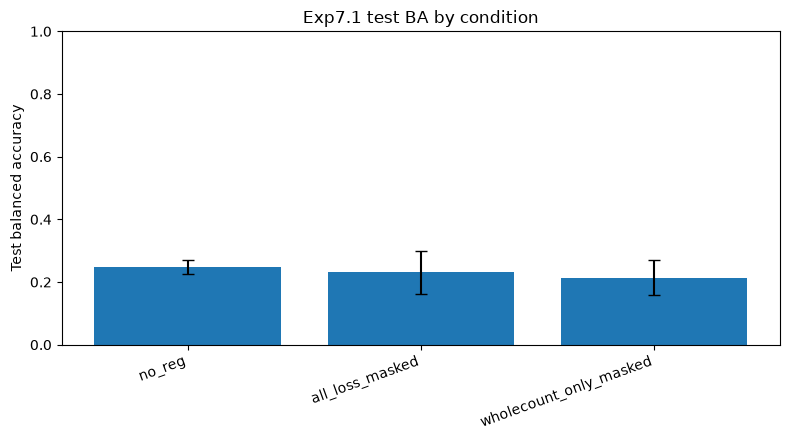

In [2]:
display(summary.set_index('condition').reindex(order).reset_index())
frame = summary.set_index('condition').reindex(order)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(frame)), frame['test_ba_mean'], yerr=frame['test_ba_std'].fillna(0), capsize=4)
ax.set_xticks(range(len(frame)))
ax.set_xticklabels(frame.index, rotation=20, ha='right')
ax.set_ylabel('Test balanced accuracy')
ax.set_ylim(0, 1)
ax.set_title('Exp7.1 test BA by condition')
plt.tight_layout()
plt.show()


## Long-layer firing dynamics

The key success criterion is not merely lower firing. A successful condition should shorten persistent runs and reduce full/padding firing while keeping long-layer activity non-zero and preserving classification.

,condition,long_valid_firing_fraction_mean,long_full_firing_fraction_mean,long_padding_firing_fraction_mean,long_mean_max_run_per_neuron_full_mean,long_p95_max_run_per_neuron_full_mean,long_current_rms_full_mean,long_weight_fro_mean
0,no_reg,0.240075,0.327133,0.368667,80.059610,234.666667,7.697954,7.103048
1,all_loss_masked,0.141403,0.193129,0.217807,46.327144,219.666667,7.399234,6.904424
2,wholecount_only_masked,0.140090,0.164628,0.176335,39.224476,204.216667,7.053761,7.024555


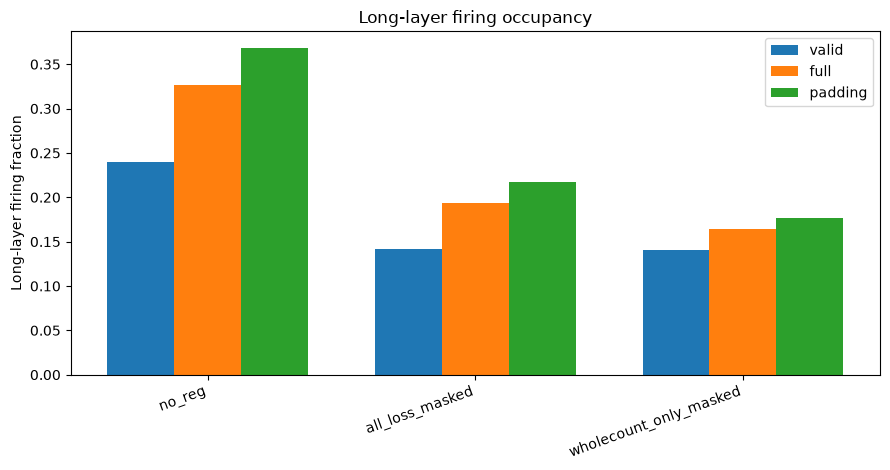

In [3]:
cols = [
    'condition',
    'long_valid_firing_fraction_mean',
    'long_full_firing_fraction_mean',
    'long_padding_firing_fraction_mean',
    'long_mean_max_run_per_neuron_full_mean',
    'long_p95_max_run_per_neuron_full_mean',
    'long_current_rms_full_mean',
    'long_weight_fro_mean',
]
view = dynamics.set_index('condition').reindex(order).reset_index()
display(view[cols])

fig, ax = plt.subplots(figsize=(9, 4.8))
x = range(len(view))
w = 0.25
ax.bar([i-w for i in x], view['long_valid_firing_fraction_mean'], width=w, label='valid')
ax.bar(list(x), view['long_full_firing_fraction_mean'], width=w, label='full')
ax.bar([i+w for i in x], view['long_padding_firing_fraction_mean'], width=w, label='padding')
ax.set_xticks(list(x))
ax.set_xticklabels(view['condition'], rotation=20, ha='right')
ax.set_ylabel('Long-layer firing fraction')
ax.set_title('Long-layer firing occupancy')
ax.legend()
plt.tight_layout()
plt.show()


## Paired condition effects

The main contrast is `wholecount_only_masked - all_loss_masked`, which isolates the effect of regularizing the complete padded trajectory rather than only the valid interval. Results below are aggregated across the paired seeds.

In [4]:
delta_cols = [c for c in paired.columns if c.endswith('_delta')]
paired_summary = paired.groupby('contrast')[delta_cols].agg(['mean', 'std'])
display(paired_summary)


test_ba_delta            \
                                                      mean       std   
contrast                                                               
all_loss_masked_minus_no_reg                     -0.016278  0.083686   
wholecount_only_masked_minus_all_loss_masked     -0.017047  0.024308   
wholecount_only_masked_minus_no_reg              -0.033325  0.066876   

                                             long_full_firing_fraction_delta  \
                                                                        mean   
contrast                                                                       
all_loss_masked_minus_no_reg                                       -0.134004   
wholecount_only_masked_minus_all_loss_masked                       -0.028501   
wholecount_only_masked_minus_no_reg                                -0.162505   

                                                        \
                                                   std   
contrast                                                 
all_loss_masked_minus_no_reg                  0.050984   
wholecount_only_masked_minus_all_loss_masked  0.022696   
wholecount_only_masked_minus_no_reg           0.073628   

                                             long_padding_firing_fraction_delta  \
                                                                           mean   
contrast                                                                          
all_loss_masked_minus_no_reg                                          -0.150860   
wholecount_only_masked_minus_all_loss_masked                          -0.041472   
wholecount_only_masked_minus_no_reg                                   -0.192332   

                                                        \
                                                   std   
contrast                                                 
all_loss_masked_minus_no_reg                  0.058876   
wholecount_only_masked_minus_all_loss_masked  0.030610   
wholecount_only_masked_minus_no_reg           0.089483   

                                             long_mean_max_run_per_neuron_full_delta  \
                                                                                mean   
contrast                                                                               
all_loss_masked_minus_no_reg                                              -33.732466   
wholecount_only_masked_minus_all_loss_masked                               -7.102668   
wholecount_only_masked_minus_no_reg                                       -40.835135   

                                                         \
                                                    std   
contrast                                                  
all_loss_masked_minus_no_reg                  12.802688   
wholecount_only_masked_minus_all_loss_masked   5.489820   
wholecount_only_masked_minus_no_reg           18.267355   

                                             long_p95_max_run_per_neuron_full_delta  \
                                                                               mean   
contrast                                                                              
all_loss_masked_minus_no_reg                                                 -15.00   
wholecount_only_masked_minus_all_loss_masked                                 -15.45   
wholecount_only_masked_minus_no_reg                                          -30.45   

                                                         \
                                                    std   
contrast                                                  
all_loss_masked_minus_no_reg                   9.165151   
wholecount_only_masked_minus_all_loss_masked  22.701487   
wholecount_only_masked_minus_no_reg           31.762517   

                                             long_current_rms_full_delta  \
                                                                    mean   
contrast            

## Gradient calibration

Regularized conditions are calibrated independently so that valid-only and full-trajectory policies have comparable initial regularizer-to-task gradient strength on `W_L`.

In [5]:
display(calibration.set_index('condition').reindex(order).reset_index())


,condition,lambda_rate_mean,lambda_rate_std,lambda_persist_mean,lambda_persist_std,achieved_rate_grad_ratio_mean,achieved_persist_grad_ratio_mean
0,no_reg,0.000000,0.000000,0.000000,0.000000,0.000,0.00
1,all_loss_masked,0.062364,0.004823,0.013881,0.001285,0.025,0.05
2,wholecount_only_masked,0.036692,0.002763,0.008262,0.000705,0.025,0.05


## Interpretation checklist

A regularized condition should only be called successful if: (1) continuous-run metrics decrease, (2) full/padding firing decreases, (3) long-layer firing remains non-zero, (4) long-current magnitude moves to a healthier regime, and (5) test BA is not materially degraded. If long activity collapses toward zero while BA survives, interpret that as pruning the long branch rather than repairing long-timescale memory.